
# Real Estate ETL + Machine Learning Project

## Dataset
World Real Estate Dataset (147K Records)

This notebook contains:
- ETL Pipeline
- Data Cleaning
- Feature Engineering
- EDA
- Outlier Removal
- Encoding
- Scaling
- Machine Learning
- Model Evaluation

Dataset:
https://www.kaggle.com/datasets/toriqulstu/worlds-real-estate-data147k


In [ ]:
# STEP 1 - INSTALL KAGGLE
# Kaggle API is required to download datasets directly in Colab

!pip install -q kaggle

In [ ]:
# STEP 2 - UPLOAD KAGGLE API FILE
# Upload kaggle.json downloaded from Kaggle account settings

from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'KGAT_f67eb03ff747d58225d4ffff3ba0929d'}

In [ ]:
# STEP 3 - CONFIGURE KAGGLE

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle Configured")

Kaggle Configured


In [ ]:
# STEP 4 - DOWNLOAD DATASET

!kaggle datasets download -d toriqulstu/worlds-real-estate-data147k

Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 10, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 763, in authenticate
    if self._authenticate_with_legacy_apikey():
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 808, in _authenticate_with_legacy_apikey
    raise ValueError("Error: Missing %s in configuration." % item)
ValueError: Error: Missing username in configuration.


In [ ]:
# STEP 5 - EXTRACT ZIP FILE

import zipfile

with zipfile.ZipFile('worlds-real-estate-data147k.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

print("Dataset Extracted")

In [11]:
# STEP 6 - IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

import joblib

print("Libraries Imported")

Libraries Imported


In [13]:
# STEP 7 - LOAD DATASET
# STEP 7 - LOAD DATASET

import os

# Show current files
print(os.listdir())

# Load dataset
df = pd.read_csv('world_real_estate_data(147k).csv')

# Show first rows
df.head()

['.config', 'world_real_estate_data(147k).csv', 'kaggle (1).json', 'kaggle.json', 'sample_data']


,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",NaN,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,NaN,NaN,NaN,NaN,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",NaN,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,NaN,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,NaN,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...


In [14]:
# STEP 8 - UNDERSTAND DATA

print("Dataset Shape:", df.shape)

print(df.columns)

df.info()

df.describe()

Dataset Shape: (147536, 14)
Index(['title', 'country', 'location', 'building_construction_year',
       'building_total_floors', 'apartment_floor', 'apartment_rooms',
       'apartment_bedrooms', 'apartment_bathrooms', 'apartment_total_area',
       'apartment_living_area', 'price_in_USD', 'image', 'url'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147536 entries, 0 to 147535
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   title                       147536 non-null  object 
 1   country                     147406 non-null  object 
 2   location                    147405 non-null  object 
 3   building_construction_year  64719 non-null   float64
 4   building_total_floors       68224 non-null   float64
 5   apartment_floor             54592 non-null   float64
 6   apartment_rooms             74178 non-null   float64
 7   apartment_bedrooms          3698

,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,price_in_USD
count,64719.000000,68224.000000,54592.000000,74178.000000,36982.000000,55973.000000,1.449610e+05
mean,1996.921754,8.575692,5.791709,2.572097,2.289222,1.364229,4.121722e+05
std,157.527635,8.356781,5.541368,1.319545,18.276913,0.745019,8.420984e+05
min,1.000000,-1.000000,-2.000000,-1.000000,-1.000000,1.000000,0.000000e+00
25%,2004.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.054200e+05
50%,2021.000000,5.000000,4.000000,2.000000,2.000000,1.000000,1.902120e+05
75%,2024.000000,14.000000,8.000000,3.000000,3.000000,2.000000,3.989300e+05
max,2316.000000,124.000000,202.000000,124.000000,2009.000000,43.000000,3.060283e+07


In [15]:
# STEP 9 - CHECK MISSING VALUES

missing = df.isnull().sum()

print(missing)

missing_percent = (missing / len(df)) * 100

print(missing_percent)

title                              0
country                          130
location                         131
building_construction_year     82817
building_total_floors          79312
apartment_floor                92944
apartment_rooms                73358
apartment_bedrooms            110554
apartment_bathrooms            91563
apartment_total_area            5740
apartment_living_area         119824
price_in_USD                    2575
image                              0
url                                0
dtype: int64
title                          0.000000
country                        0.088114
location                       0.088792
building_construction_year    56.133418
building_total_floors         53.757727
apartment_floor               62.997506
apartment_rooms               49.722102
apartment_bedrooms            74.933576
apartment_bathrooms           62.061463
apartment_total_area           3.890576
apartment_living_area         81.216788
price_in_USD                 

In [16]:
# STEP 10 - REMOVE DUPLICATES

before = len(df)

df.drop_duplicates(inplace=True)

after = len(df)

print("Duplicates Removed:", before - after)

Duplicates Removed: 0


In [17]:
# STEP 11 - REMOVE UNNECESSARY COLUMNS

# Some columns like image URLs are not useful for ML

df.drop(columns=['Image', 'URL'],
        inplace=True,
        errors='ignore')

print("Columns Removed")

Columns Removed


In [18]:
# STEP 12 - HANDLE MISSING VALUES

# Separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

# Numerical columns -> median
num_imputer = SimpleImputer(strategy='median')

df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

# Categorical columns -> most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

print("Missing Values Handled")

Missing Values Handled


In [19]:
# STEP 13 - FEATURE ENGINEERING

CURRENT_YEAR = 2026

# Property Age

if 'Building Construction Year' in df.columns:
    df['Property_Age'] = (
        CURRENT_YEAR -
        df['Building Construction Year']
    )

# Price Per Room

if ('Price in USD' in df.columns and
    'Apartment Rooms' in df.columns):

    df['Price_Per_Room'] = (
        df['Price in USD'] /
        (df['Apartment Rooms'] + 1)
    )

# Area Per Room

if ('Apartment Total Area' in df.columns and
    'Apartment Rooms' in df.columns):

    df['Area_Per_Room'] = (
        df['Apartment Total Area'] /
        (df['Apartment Rooms'] + 1)
    )

df.head()

,title,country,location,building_construction_year,building_total_floors,apartment_floor,apartment_rooms,apartment_bedrooms,apartment_bathrooms,apartment_total_area,apartment_living_area,price_in_USD,image,url
0,2 room apartment 120 m² in Mediterranean Regio...,Turkey,"Mediterranean Region, Turkey",2021.0,5.0,1.0,3.0,2.0,2.0,120 m²,110 m²,315209.0,https://realting.com/uploads/bigSlider/ab3/888...,https://realting.com/property-for-sale/turkey/...
1,"4 room villa 500 m² in Kalkan, Turkey",Turkey,"Kalkan, Mediterranean Region, Kas, Turkey",2021.0,2.0,4.0,2.0,2.0,1.0,500 m²,480 m²,1108667.0,https://realting.com/uploads/bigSlider/87b/679...,https://realting.com/property-for-sale/turkey/...
2,"1 room apartment 65 m² in Antalya, Turkey",Turkey,"Mediterranean Region, Antalya, Turkey",2021.0,5.0,2.0,2.0,1.0,1.0,65 m²,60 m²,173211.0,https://realting.com/uploads/bigSlider/030/a11...,https://realting.com/property-for-sale/turkey/...
3,"1 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2020.0,15.0,5.0,2.0,1.0,1.0,100 m²,40 m²,99900.0,https://realting.com/uploads/bigSlider/e9a/e06...,https://realting.com/property-for-sale/thailan...
4,"2 room apartment in Pattaya, Thailand",Thailand,"Chon Buri Province, Pattaya, Thailand",2026.0,8.0,3.0,3.0,2.0,1.0,100 m²,36 m²,67000.0,https://realting.com/uploads/bigSlider/453/aa2...,https://realting.com/property-for-sale/thailan...


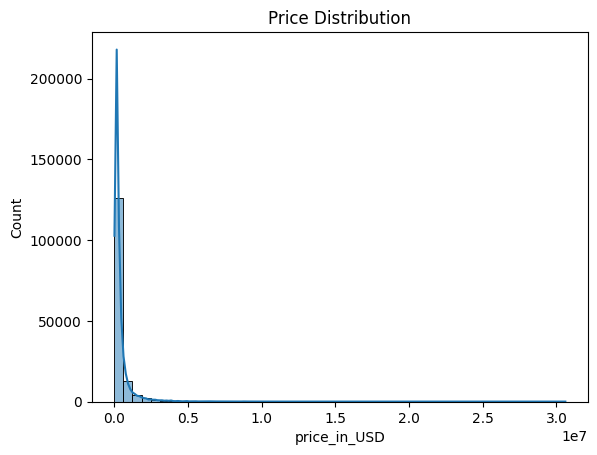

In [28]:
# STEP 14 - EDA
if 'price_in_USD' in df.columns:

    sns.histplot(df['price_in_USD'],
                 bins=50,
                 kde=True)

    plt.title("Price Distribution")
    plt.show()

else:
    print("Column not found")

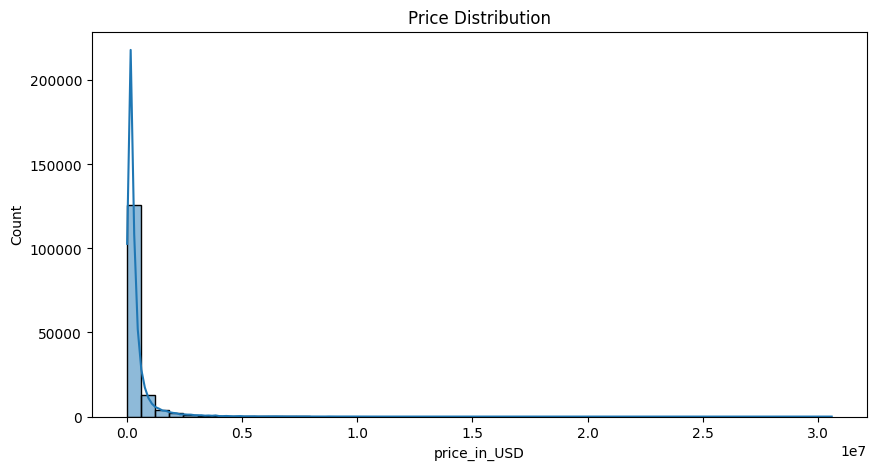

In [24]:
# STEP 15 - TOP COUNTRIES

# STEP 14 - EDA

plt.figure(figsize=(10,5))

sns.histplot(df['price_in_USD'],
             bins=50,
             kde=True)

plt.title("Price Distribution")

plt.show()

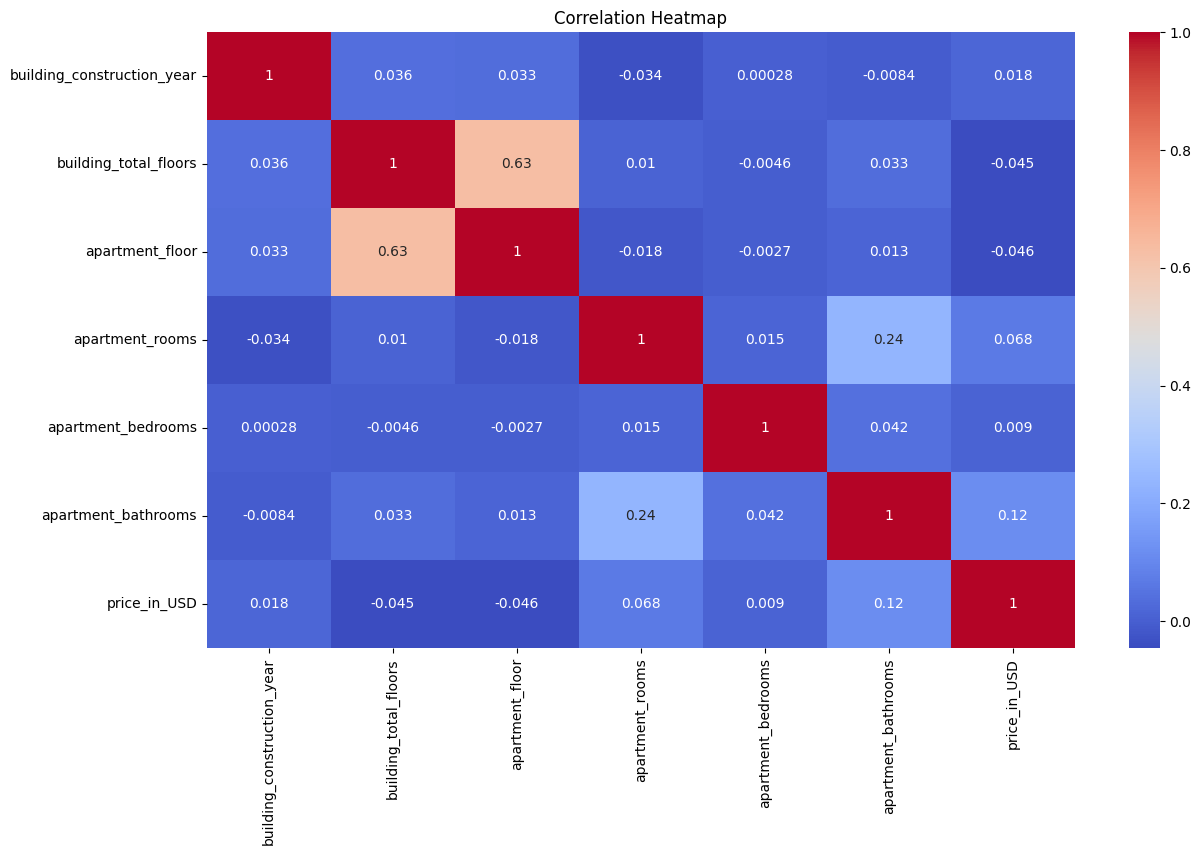

In [25]:
# STEP 16 - CORRELATION HEATMAP

plt.figure(figsize=(14,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

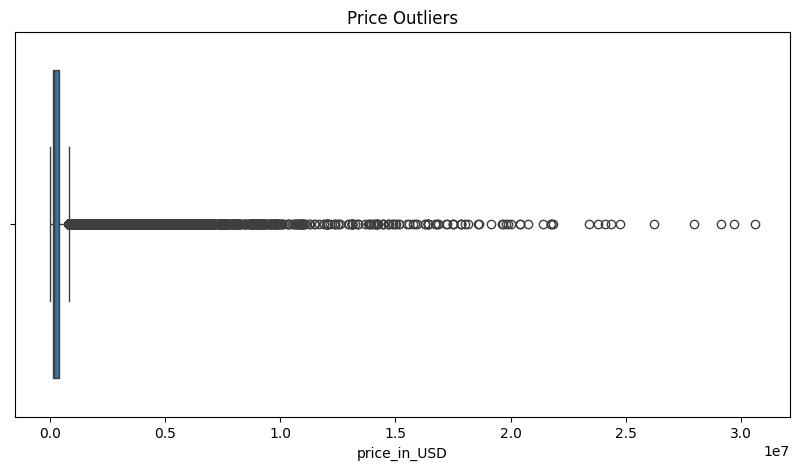

In [30]:
# STEP 17 - OUTLIER DETECTION

plt.figure(figsize=(10,5))

sns.boxplot(x=df['price_in_USD'])

plt.title("Price Outliers")

plt.show()

In [32]:
# STEP 18 - REMOVE OUTLIERS USING IQR

Q1 = df['price_in_USD'].quantile(0.25)

Q3 = df['price_in_USD'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    (df['price_in_USD'] >= lower_limit) &
    (df['price_in_USD'] <= upper_limit)
]

print(df.shape)

(132573, 14)


In [33]:
# STEP 19 - ENCODE CATEGORICAL DATA

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

print("Encoding Completed")

Encoding Completed


In [35]:
# STEP 20 - FEATURES AND TARGET

# STEP 20 - FEATURES AND TARGET

y = df['price_in_USD']

X = df.drop(columns=['price_in_USD'])

print(X.shape)
print(y.shape)

(132573, 13)
(132573,)


In [36]:
# STEP 21 - TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(106058, 13)
(26515, 13)


In [37]:
# STEP 22 - FEATURE SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


In [38]:
# STEP 23 - LINEAR REGRESSION

lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

lr_predictions = lr_model.predict(X_test_scaled)

print("Linear Regression Trained")

Linear Regression Trained


In [39]:
# STEP 24 - EVALUATE LINEAR REGRESSION

mae = mean_absolute_error(y_test, lr_predictions)

mse = mean_squared_error(y_test, lr_predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, lr_predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 117502.2887951017
MSE : 24231077149.31155
RMSE: 155663.34555479512
R2  : 0.2033133413734004


In [40]:
# STEP 25 - RANDOM FOREST MODEL

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest Trained")

Random Forest Trained


In [41]:
# STEP 26 - RANDOM FOREST EVALUATION

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_mse = mean_squared_error(y_test, rf_predictions)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_predictions)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

MAE : 59712.795104657744
MSE : 9510465173.745987
RMSE: 97521.61387992914
R2  : 0.6873081343199138


In [42]:
# STEP 27 - FEATURE IMPORTANCE

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df.head(15))

                       Feature  Importance
9         apartment_total_area    0.253462
12                         url    0.249429
0                        title    0.217258
2                     location    0.091242
11                       image    0.064082
3   building_construction_year    0.028536
4        building_total_floors    0.025812
1                      country    0.018106
10       apartment_living_area    0.015478
6              apartment_rooms    0.012606
5              apartment_floor    0.010278
8          apartment_bathrooms    0.008445
7           apartment_bedrooms    0.005267


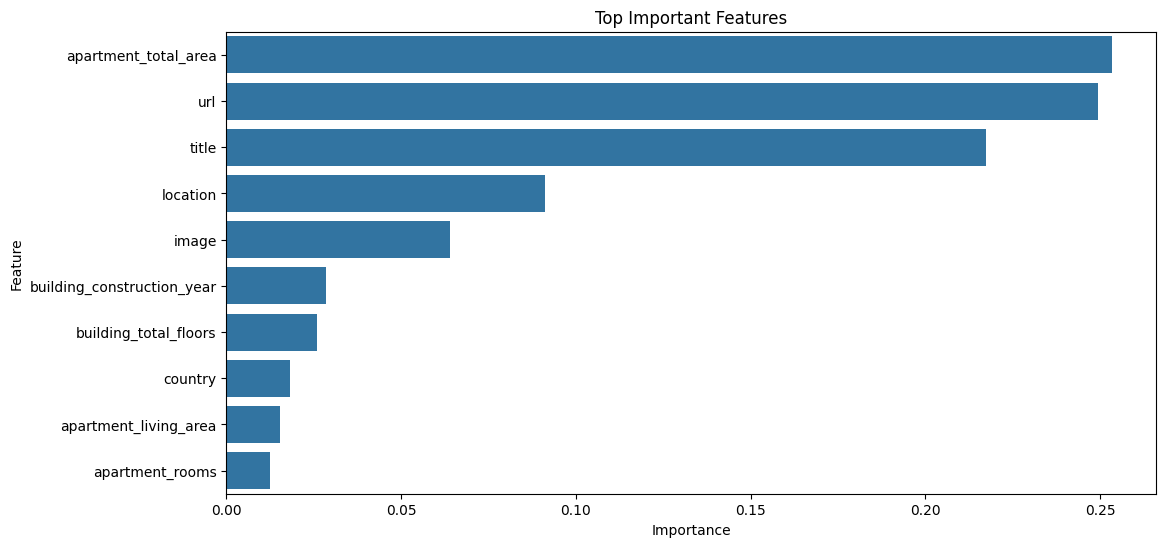

In [43]:
# STEP 28 - VISUALIZE FEATURE IMPORTANCE

plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df.head(10)
)

plt.title("Top Important Features")

plt.show()

In [44]:
# STEP 29 - SAVE MODEL

joblib.dump(
    rf_model,
    'real_estate_model.pkl'
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

print("Model Saved")

Model Saved


In [45]:
# STEP 30 - MAKE PREDICTION

sample = X_test.iloc[0:1]

prediction = rf_model.predict(sample)

print("Predicted Price:", prediction[0])

print("Actual Price:", y_test.iloc[0])

Predicted Price: 174872.36
Actual Price: 170858.0
